In [535]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation

In [536]:
#Параметры разных типов сосудов. Удобно, что в модели можно менять название сосуда и автоматически везде подставятся нужны геометрические значения
vessels_params = {
   "arteriole": {
    "r_m": 30e-6,           # радиус ~30 µm
    "L_m": 3e-3,            # длина сегмента ~3 мм***
    "Q_m3_s": 1.5e-11,      # поток ~0.5–1e-12 м³/с
    "Q_pulse_frac": 0.1,
    "f_Hz": 1,
    "mu_Pa_s": 0.0035
}
,
    "small_artery": {
    "r_m": 0.25e-3,        
    "L_m": 0.02,            
    "Q_m3_s": 5e-9,         
    "Q_pulse_frac": 0.15,
    "f_Hz": 1,
    "mu_Pa_s": 0.0035
}
,
    "medium_artery": {
        "r_m": 3e-3,           
        "L_m": 0.03,            
        "Q_m3_s": 1e-5,         
        "Q_pulse_frac": 0.2,
        "f_Hz": 1,
        "mu_Pa_s": 0.0035
    },
    "aorta": {
        "r_m": 0.012,           
        "L_m": 0.1,             
        "Q_m3_s": 5e-5,         
        "Q_pulse_frac": 0.3,
        "f_Hz": 1,
        "mu_Pa_s": 0.0035
    }
}

In [537]:
# ===== Функция для расчета сдвигового напряжения с пульсацией =====
def tau_from_vessel(vessel_type, t=0, units='dyn/cm2'):
    if vessel_type not in vessels_params:
        raise ValueError(f"Unknown vessel type: {vessel_type}")

    p = vessels_params[vessel_type]

    # исходный пульсирующий поток
    Q = p["Q_m3_s"] * (1 + p["Q_pulse_frac"] * np.sin(2 * np.pi * p["f_Hz"] * t))

    # после 500 с поток уменьшается в 10 раз
    if t >= 800 and t < 1200:
        Q *= 0.5
    elif t >= 1200:
        Q *= 0.1

    tau = 4 * p["mu_Pa_s"] * Q / (np.pi * p["r_m"]**3)

    if units == 'dyn/cm2':
        tau *= 10  # Pa -> dyn/cm²

    return tau

In [538]:
# ===== Функция для расчета сдвигового напряжения БЕЗ пульсацией =====
def tau_from_vessel(vessel_type, t=0, units='dyn/cm2'):
    if vessel_type not in vessels_params:
        raise ValueError(f"Unknown vessel type: {vessel_type}")

    p = vessels_params[vessel_type]

    # исходный пульсирующий поток
    Q = p["Q_m3_s"] 

    # после 500 с поток уменьшается в 10 раз
    if t >= 0 and t < 10:
        Q *= 0
    elif t >= 10 and t < 30:
        Q *= 0.0404
    elif t >= 30 and t < 60:
        Q *= 0.0808
    elif t >= 60 and t < 90:
        Q *= 0.1212
    elif t >= 90 and t < 120:
        Q *= 0.1616
    elif t >= 120 and t < 150:
        Q *= 0.2020
    elif t >= 150 and t < 180:
        Q *= 0.2424
    elif t >= 180 and t < 210:
        Q *= 0.2828
    elif t >= 210 and t < 240:
        Q *= 0.3232
    elif t >= 240 and t < 270:
        Q *= 0.4040
    elif t >= 270 and t < 300:
        Q *= 0.4444
    elif t >= 300 and t < 330:
        Q *= 0.4848
    elif t >= 330 and t < 360:
        Q *= 0.2424
    elif t >= 360 and t < 390:
        Q *= 0.3232
    elif t >= 390:
        Q *= 0.2424


    tau = 4 * p["mu_Pa_s"] * Q / (np.pi * p["r_m"]**3)

    if units == 'dyn/cm2':
        tau *= 10  # Pa -> dyn/cm²

    return tau

In [539]:
#функция, которая задает профиль скоростей в просвете сосуда
#Статья A Computational Model of Nitric Oxide Production and Transport in a Parallel Plate Flow Chamber
def velocity_profile(y, t, params):
    r_m = params["r_m"]
    h = 2 * r_m             
    w = params["L_m"]               
    Q_mean = params["Q_m3_s"]
    frac = params["Q_pulse_frac"]
    f = params["f_Hz"]
    Q_t = Q_mean * (1 + frac * np.sin(2 * np.pi * f * t))
    V_avg = Q_t / (w * h)
    U = 1.5 * V_avg
    term = (y / h) - (y / h)**2
    return U * term * 4

In [540]:
#Функция, которая описывает концентрацию тромбоцитов в сосуде
#Model of platelet transport in flowing blood with drift and diffusion terms
def platelet_concentration(x, vessel_type, vessels_params):

    Plt0=4.15e-13
    m=19
    n=2
    K=0.8 * m * (m + 1)
    r_m = vessels_params[vessel_type]["r_m"]
    R = 1 - x / r_m
    Plt = Plt0 * (1 + K * (R**(m-1)) * ((1-R)**(n-1)))
    return Plt

In [541]:
#Функция, которая описывает откачку Ca из сосуда
def calcium_fluxes(Ca, Cab): #A mathematical model of cytosolic calcium dynamics in human umbilical vein endothelial cells 

    # ===== Буфферизация =====
    BT = 120e-6          # 120 µM
    k6 = 100 * 1e6           # M⁻¹ s⁻¹
    k7 = 300             # s⁻¹
    # ===== Ca-ATPase =====
    Vp = 1.63e-6         # 1.63 µM/s
    Vhi = 4.76e-6        # 2.38 µM/s
    K4 = 0.08e-6         # 0.08 µM
    Khi = 0.38e-6        # 0.38 µM

    # ===== Na/Ca exchanger =====
    Vex = 18.33e-6       # 18.33 µM/s
    K5 = 0.321e-6        # 0.321 µM

    # ===== Буферизация =====
    q_b = k6 * Ca * (BT - Cab) - k7 * Cab

    # ===== Ca-ATPase =====
    q_ATPase = (
        Vp * Ca**1.7 / (K4**1.7 + Ca**1.7)
        + Vhi * Ca**4.4 / (Khi**4.4 + Ca**4.4)
    )
    # ===== Na/Ca exchanger =====
    q_ex = Vex * Ca / (K5 + Ca)

    # ===== Общий вывод =====
    q_out = q_ATPase + q_ex

    return q_out, q_b

In [542]:
#Функция вероятности открытия Пьезо1 от напряжения сдвига
#Physics of mechanotransduction by Piezo ion channels
def piezo1_open_probability(tension_dyn_cm):
    delta_g0_kT=9.0 #Physics of mechanotransduction by Piezo ion channels
    delta_a_nm2=5.9 #Physics of mechanotransduction by Piezo ion channels
    temperature_K=310.0
    kB = 1.380649e-23
    kBT = kB * temperature_K

    tension_SI = tension_dyn_cm * 1e-3   # dyn/cm -> N/m
    delta_a_SI = delta_a_nm2 * 1e-18                 # nm^2 -> m^2
    delta_g0 = delta_g0_kT * kBT

    delta_G = delta_g0 - delta_a_SI * tension_SI
    Po = 1.0 / (1.0 + np.exp(delta_G / kBT))
    return Po

In [543]:
#модель изменения концентрации Ca внутри клетки. Была проблема с объемом клетки, так как упустил тот факт, что нужны литры, а не м^3. Сейчас поэтому лучше работает q_in_x = -N_open * f_g_Ca * Vm / (z * F * Vc_x)
def ca_model(t, y, vessel_type):
    # ===== Переменные =====
    Ca, Cab, N_open, N_inact, N_cl = y

    # ===== Shear stress =====
    tau_shear = tau_from_vessel(vessel_type, t, units='dyn/cm2')

    # ===== Параметры Piezo1=====
    tau_inact = 0.0656                      # Piezo1, a mechanically activated ion channel, is required for vascular development in mice
    k_inact = 1 / tau_inact
    tau_rec = 0.024                         # Transduction of repetitive mechanical stimuli by Piezo1 and Piezo2 ion channels
    k_rec = 1 / tau_rec
    N_total = 1000                          # каналов на клетку, 1-2 канала/мкм,2 Piezo1 ion channels inherently function as independent mechanotransducers
    f_g_Ca = 15e-12

    # ===== P_0 =====
    p_o = piezo1_open_probability(tau_shear)

    # ===== k_open с Wiesner sensitization A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress =====
    k_open = 1 * p_o   # A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress в статье говорится, что константа открытия как раз пропорциональна вероятности открытия

    # ===== 3-state Markov модель Piezo1 Human PIEZO1: Removing Inactivation =====
    dN_open_dt  = k_open * N_cl - k_inact * N_open
    dN_inact_dt = k_inact * N_open - k_rec * N_inact
    dN_cl_dt    = k_rec * N_inact - k_open * N_cl


    R, T_phys, F = 8.314, 310, 96485
    Vm = -40e-3         # V Contributions of K+, Na+, and Cl- to the membrane potential of intact hamster vascular endothelial cells
    Ca_o = 1.5e-3       # M
    z = 2
    #Vc = 15000e-18        # л³  The shape of the EC varies along the vascular tree, but they are generally thin and slightly elongated, their dimensions described to be roughly 30–50 µm in length, 10–30 µm wide and a thickness of 0.1–10 µm
    Vc_x = 10000e-15      #Endothelial cell subpopulations in vitro: cell volume, cell cycle, and radiosensitivity 1,009 +- 170
    
    #Endothelial cell subpopulations in vitro: cell volume, cell cycle, and radiosensitivity 1,009 +- 170


    # Поток через все открытые каналы (моль/с) A mathematical model of the cytosolic-free calcium response in endothelial cells to fluid shearstress
    #exp_term = np.exp(-z * F * Vm / (R * T_phys))
    #q_in_mol = -N_open * f_g_Ca * Vm / (z * F) * (Ca - Ca_o * exp_term) / (1 - exp_term)
    #q_in = q_in_mol / Vc
    q_in_x = -N_open * f_g_Ca * Vm / (z * F * Vc_x)

    # ===== Откачка и буфер Ca²⁺ =====
    q_out, q_b = calcium_fluxes(Ca, Cab)
    dCa_dt = q_in_x - q_out - q_b 
    dCab_dt = q_b
    

    # Ограничения на отрицательные концентрации
    #if Ca <= 0 and dCa_dt < 0: dCa_dt = 0
    #if Cab <= 0 and dCab_dt < 0: dCab_dt = 0

    return [dCa_dt, dCab_dt, dN_open_dt, dN_inact_dt, dN_cl_dt]


In [544]:
# Модель NO
#Shear‑Induced Nitric Oxide Production by Endothelial Cells
def no_model(t, y, Ca_profile, vessel_type):
    Ca4CaM, eNOS_CaM, eNOS_CaM_star, eNOS0cav, NO, cGMP, AKT_star, PKC_star = y

    # ===== Входные параметры =====
    Ca = Ca_profile(t)                              # моль/л (M)
    tau_shear = tau_from_vessel(vessel_type, t, units='dyn/cm2')  # dyn/cm² (без пересчёта)

    # ===== Константы (переведены в моль/л) =====
    # CaM (Eq.17): первоначально в µM → умножаем на 1e-6
    k_Ca4_CaM   = 100.0        # s⁻¹
    k_minus_Ca4CaM = 1.0      # s⁻¹
    beta        = 2.7
    theta       = 0.0045
    K_d_CaM     = 1e-6  # 1 µM → 1e-6 M
    CaM_tot     = 30e-6  # 30 µM → 30e-6 M

    # eNOS‑CaM (Eq.18)
    k_plus_CaM      = 7.5      # s⁻¹
    k_minus_CaM     = 0.01     # s⁻¹
    K_0_5_CaM       = 3e-6  # 3 µM → 3e-6 M
    eNOS_tot        = 0.04e-6 # 0.04 µM → 0.04e-6 M

    # eNOS‑CaM* (Eq.19)
    k_eAKT_max      = 0.004        # s⁻¹
    k_eAKT_minus    = 2.22e-4      # s⁻¹
    AKT_tot         = 1e-6  # 1 µM → 1e-6 M

    # PKC inhibition (Eq.20)
    k_Thr_plus      = 0.002
    k_Thr_minus     = 2.22e-4
    PKC_tot         = 1e-6   # 1 µM → 1e-6 M

    # NO production (Eq.22–26)
    Upsilon         = 300.0
    phi             = 9.0
    R_max_NO        = 0.022
    lambda_NO       = 382.0

    # a0, a1, b1, g0, g1: изначально в nM → нужно пересчитать в M
    a0_nM2 = 1200.16   # nM² → M²: 1 nM² = 1e-18 M²
    a1_nM  = 37.33     # nM  → 1e-9 M
    b1_nM  = 15.15     # nM  → 1e-9 M
    g0_nM2 = 4.8       # nM² → 1e-18 M²
    g1_nM  = 35.33     # nM  → 1e-9 M

    a0 = a0_nM2 * 1e-18   # M²
    a1 = a1_nM  * 1e-9    # M
    b1 = b1_nM  * 1e-9    # M
    g0 = g0_nM2 * 1e-18   # M²
    g1 = g1_nM  * 1e-9    # M

    sGC_tot         = 0.1e-6   # 0.1 µM → 0.1e-6 M

    # cGMP (Eq.27)
    V_max_cGMP      = 1.26e-6         # µM/s → нужно в M/s

    X               = 0.0695          # s⁻¹ (не меняется, т.к. без концентрации)
    K_cGMP          = 2e-6    # 2 µM → 2e-6 M (в M)


    # ===== 1. Ca4‑CaM =====
    term_Ca4CaM = theta * (Ca**beta) / (K_d_CaM**beta + Ca**beta)
    dCa4CaM_dt = k_Ca4_CaM * term_Ca4CaM * CaM_tot - k_minus_Ca4CaM * Ca4CaM


    # ===== 2. eNOS_cav =====
    eNOS_cav = eNOS_tot - eNOS_CaM - eNOS_CaM_star - eNOS0cav


    # ===== 3. eNOS‑CaM =====
    forward_eNOS_CaM = k_plus_CaM * (Ca4CaM / (K_0_5_CaM + Ca4CaM)) * eNOS_cav
    backward_eNOS_CaM = k_minus_CaM * eNOS_CaM
    d_eNOS_CaM_dt = forward_eNOS_CaM - backward_eNOS_CaM


    # ===== 4. eNOS‑CaM* (phosphorylation by AKT) =====
    tau_50_AKT  = 15.0      # dyn/cm²
    n_Hill_AKT  = 2
    AKT_active_rate = k_eAKT_max * (
        tau_shear**n_Hill_AKT / (tau_50_AKT**n_Hill_AKT + tau_shear**n_Hill_AKT)
    )

    k_eAKT_plus         = AKT_active_rate * (AKT_star / AKT_tot)
    d_eNOS_CaM_star_dt  = k_eAKT_plus * eNOS_CaM - k_eAKT_minus * eNOS_CaM_star

    # вычитаем расход eNOS‑CaM на превращение в CaM*
    d_eNOS_CaM_dt -= k_eAKT_plus * eNOS_CaM


    # ===== 5. PKC inhibition → eNOS0cav =====
    tau_50_PKC  = 24.0
    n_Hill_PKC  = 2
    PKC_active_rate = k_Thr_plus * (
        tau_shear**n_Hill_PKC / (tau_50_PKC**n_Hill_PKC + tau_shear**n_Hill_PKC)
    )

    forward_eNOS0cav = PKC_active_rate * (PKC_star / PKC_tot) * eNOS_cav
    backward_eNOS0cav = k_Thr_minus * eNOS0cav
    d_eNOS0cav_dt = forward_eNOS0cav - backward_eNOS0cav


    # ===== 6. NO production =====
    R_NO        = Upsilon * (eNOS_CaM + phi * eNOS_CaM_star)
    denom_sGC   = a0 + a1 * NO + NO**2
    Q_sGC       = R_max_NO * (NO**2 + b1 * NO) / denom_sGC * sGC_tot
    d_NO_dt     = R_NO - Q_sGC - lambda_NO * NO


    # ===== 7. cGMP =====
    dcGMP_prod  = V_max_cGMP * (g0 + g1 * NO + NO**2) / (a0 + a1 * NO + NO**2)
    dcGMP_dt    = dcGMP_prod - X * (cGMP**2 / (K_cGMP + cGMP))


    # ===== 8. AKT & PKC dynamics =====
    d_AKT_star_dt = AKT_active_rate * (1 - AKT_star / AKT_tot) - 0.1155 * AKT_star
    d_PKC_star_dt = PKC_active_rate * (1 - PKC_star / PKC_tot) - 0.1155 * PKC_star


    return [
        dCa4CaM_dt,
        d_eNOS_CaM_dt,
        d_eNOS_CaM_star_dt,
        d_eNOS0cav_dt,
        d_NO_dt,
        dcGMP_dt,
        d_AKT_star_dt,
        d_PKC_star_dt
    ]


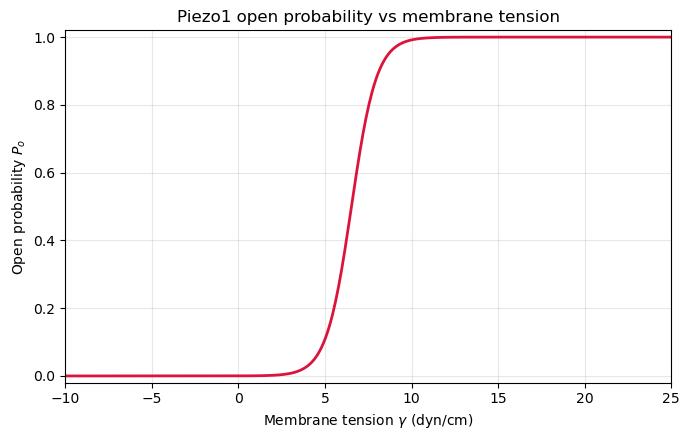

In [545]:
#Зависимость вероятности открытия канала Пьезо1 от напряжения сдвига
gamma = np.linspace(-10, 25, 400)  # dyn/cm
Po = piezo1_open_probability(gamma)

plt.figure(figsize=(7, 4.5))
plt.plot(gamma, Po, lw=2, color="crimson")
plt.xlabel("Membrane tension $\gamma$ (dyn/cm)")
plt.ylabel("Open probability $P_o$")
plt.title("Piezo1 open probability vs membrane tension")
plt.ylim(-0.02, 1.02)
plt.xlim(gamma.min(), gamma.max())
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [546]:
for name in ["arteriole", "medium_artery",'small_artery', 'aorta']:
    tau = tau_from_vessel(name, t=0)
    print(f"{name}: {tau:.1f} dyn/cm²")


arteriole: 0.0 dyn/cm²
medium_artery: 0.0 dyn/cm²
small_artery: 0.0 dyn/cm²
aorta: 0.0 dyn/cm²


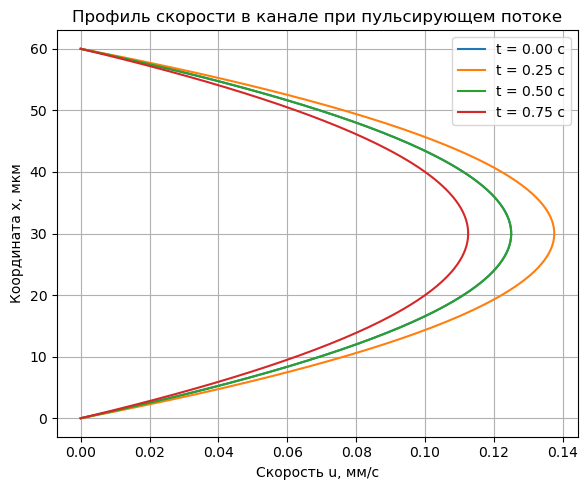

In [547]:
#Профиль скоростей
# Выбираем тип сосуда
vessel_type = "arteriole" 
r_m = vessels_params[vessel_type]["r_m"]
h = 2 * r_m
# координата x (от стенки до стенки)
x = np.linspace(0, r_m, 200)
x_vessel = np.linspace(0, h, 200)
T = 1 / vessels_params[vessel_type]["f_Hz"]
times = [0, T/4, T/2, 3*T/4]
plt.figure(figsize=(6,5))

for t in times:
    u = velocity_profile(x_vessel, t, vessels_params[vessel_type])
    plt.plot(u * 1e3, x_vessel * 1e6, label=f"t = {t:.2f} c")

plt.xlabel("Скорость u, мм/с")
plt.ylabel("Координата x, мкм")
plt.title("Профиль скорости в канале при пульсирующем потоке")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

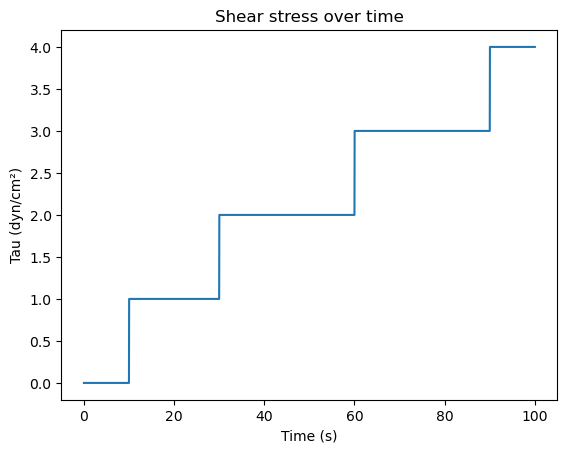

In [548]:
# График напряжения сдвига 
t_span = (0, 100)  # секунды
t = np.linspace(*t_span, 5000)

tau_values = [tau_from_vessel(vessel_type, ti) for ti in t]

plt.figure()
plt.plot(t, tau_values)
plt.xlabel("Time (s)")
plt.ylabel("Tau (dyn/cm²)")
plt.title("Shear stress over time")
plt.show()

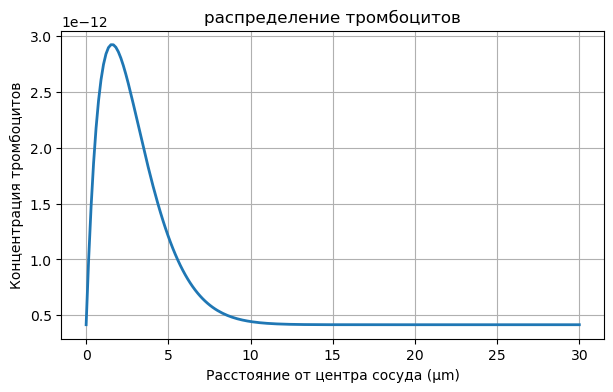

In [549]:
#График распределения тромбоцитов
plt_vals = platelet_concentration(x, vessel_type, vessels_params)

# график
plt.figure(figsize=(7,4))
plt.plot(x * 1e6, plt_vals, linewidth=2)

plt.xlabel("Расстояние от центра сосуда (µm)")
plt.ylabel("Концентрация тромбоцитов")
plt.title("распределение тромбоцитов")
plt.grid(True)

plt.show()

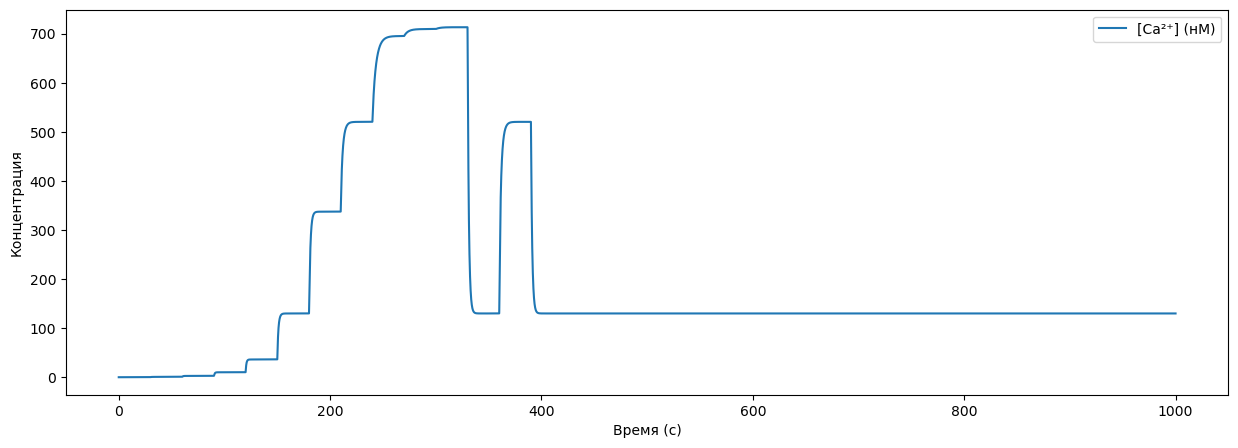

In [550]:
# ===== Начальные условия =====
Ca0 = 50e-9       # 50 нМ
Cab0 =2e-6       # буфер
Ca0 = 0      # 0 нМ
Cab0 = 0      # буфер
N_total = 1000
N_op0 = N_total * 0.00    # открытые каналы
N_inact0 = 0                 # инактивированные
N_cl0 = N_total - N_op0 - N_inact0   # закрытые


y0 = [Ca0, Cab0, N_op0, N_inact0, N_cl0]

t_span = (0, 1000)  # время интегрирования уравнения

# ===== Функция интеграции =====
sol_ca  = solve_ivp(
    fun=lambda t, y: ca_model(t, y, vessel_type),
    t_span=t_span,
    y0=y0,
    max_step=0.05,
    dense_output=True, 
    method="BDF"
)

# ===== Доступ к результатам =====
t = sol_ca.t
Ca = sol_ca.y[0]
Cab = sol_ca.y[1]
N_open = sol_ca.y[2]
N_inact = sol_ca.y[3]
N_cl = sol_ca.y[4]



x = 15
y = 5
plt.figure(figsize=(x,y))
plt.plot(t, Ca*1e9, label='[Ca²⁺] (нМ)')
plt.xlabel('Время (с)')
plt.ylabel('Концентрация')
plt.legend()
plt.show()

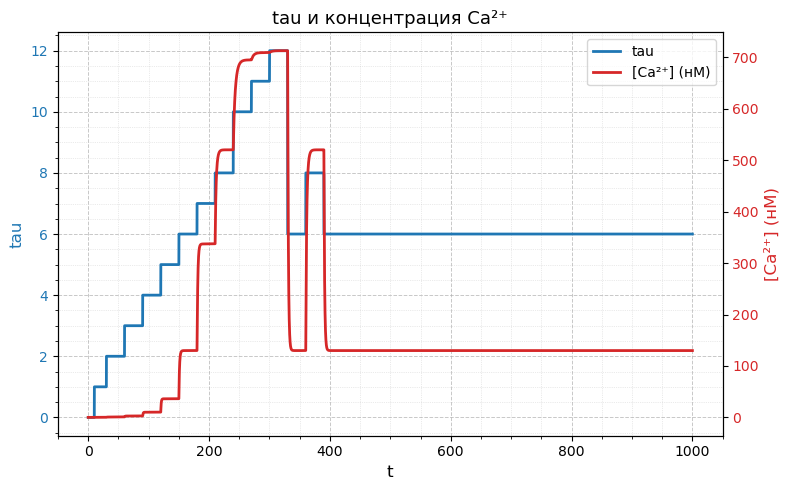

In [551]:
#График напряжения сдвига и концентрации кальция от времени
fig, ax1 = plt.subplots(figsize=(8, 5))

# Цвета (задаём явно)
color_tau = 'tab:blue'
color_ca = 'tab:red'

# Первая ось Y — tau
tau_vals = np.array([tau_from_vessel(vessel_type, ti) for ti in t])
line1, = ax1.plot(t, tau_vals, label='tau', color=color_tau, linewidth=2)

ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('tau', fontsize=12, color=color_tau)
ax1.tick_params(axis='y', labelcolor=color_tau)

# Сетка
ax1.minorticks_on()
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# Вторая ось Y — Ca
ax2 = ax1.twinx()
line2, = ax2.plot(t, Ca * 1e9, label='[Ca²⁺] (нМ)', color=color_ca, linewidth=2)

ax2.set_ylabel('[Ca²⁺] (нМ)', fontsize=12, color=color_ca)
ax2.tick_params(axis='y', labelcolor=color_ca)

# Одинаковый стиль для подписей осей
for ax in [ax1, ax2]:
    ax.yaxis.label.set_fontsize(12)
    ax.xaxis.label.set_fontsize(12)

# Общая легенда
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title('tau и концентрация Ca²⁺', fontsize=13)
plt.tight_layout()
plt.show()

<Figure size 1500x500 with 0 Axes>

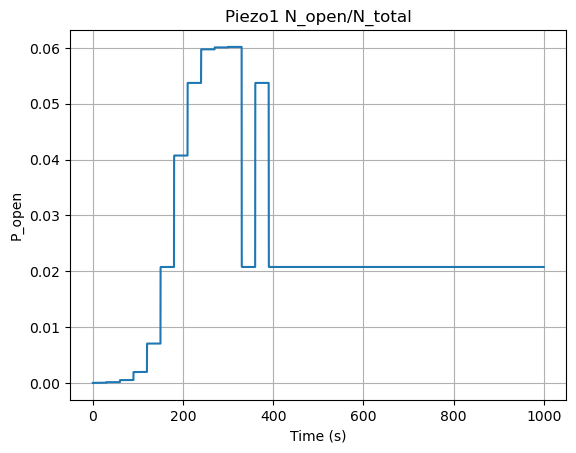

In [552]:
# график части открытых каналов пьезо1 от времени
plt.figure(figsize=(x,y))
plt.figure()
plt.plot(t, N_open/N_total)
plt.xlabel("Time (s)")
plt.ylabel("P_open")
plt.title("Piezo1 N_open/N_total")
plt.grid()
plt.show()

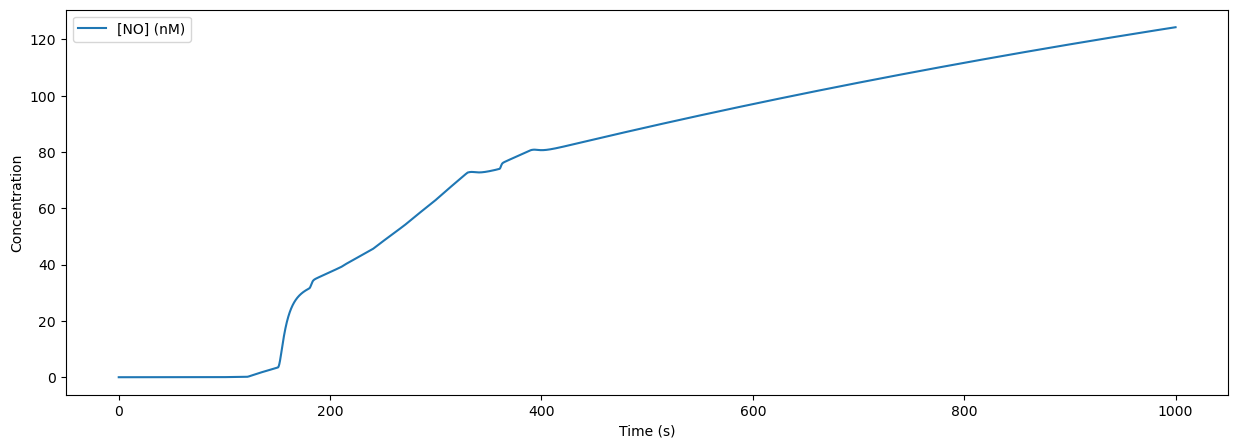

In [553]:
# строим решени концентрации NO от времени
Ca_interp = lambda t: sol_ca.sol(t)[0]   

# Шаг 2: решаем NO модель с Ca(t)
y0_no = [
    0,    # Ca4CaM0
    0,   # eNOS_CaM0  
    0,  # eNOS_CaM_star0
    0,  # eNOS0cav0
    0,  # NO0
    0,   # cGMP0
    0,    # AKT_star0
    0    # PKC_star0
]

#0.001e-6,  # NO0
sol_no = solve_ivp(
    lambda t, y: no_model(t, y, Ca_interp, vessel_type),
    t_span,
    y0_no,
    method='BDF',
    max_step=0.05,
    dense_output=True
)


t_NO = sol_no.t
NO = sol_no.y[4]
plt.figure(figsize=(x,y))
plt.plot(t_NO, NO*1e9, label='[NO] (nM)')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Concentration')
plt.show()

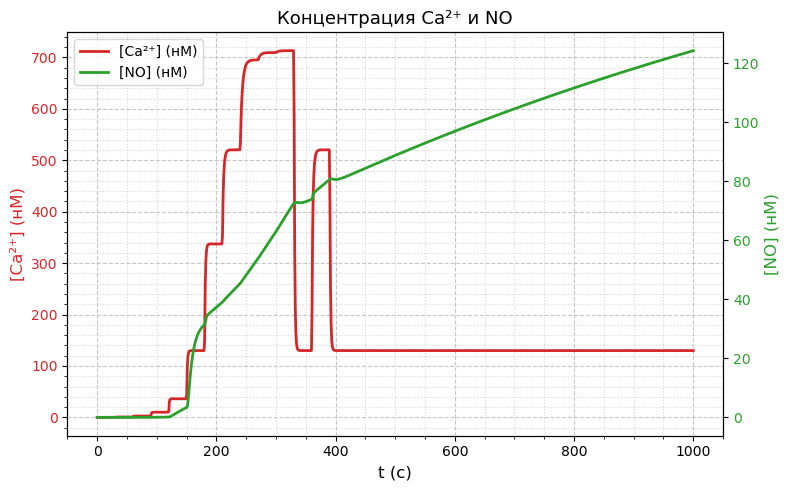

In [554]:
#График напряжения концентрации NO и концентрации кальция от времени
# ===== Используем t_Ca и t_NO из решения ODE =====
t_Ca = sol_ca.t
Ca = sol_ca.y[0]

t_NO = sol_no.t
NO = sol_no.y[4]

# ===== Общий массив времени для графика =====
t_common = np.linspace(max(t_Ca[0], t_NO[0]), min(t_Ca[-1], t_NO[-1]), 1000)

# ===== Интерполяция =====
f_Ca = interp1d(t_Ca, Ca*1e9, kind='linear', fill_value="extrapolate")
f_NO = interp1d(t_NO, NO*1e9, kind='linear', fill_value="extrapolate")

Ca_interp = f_Ca(t_common)
NO_interp = f_NO(t_common)

# ===== Построение графика =====
fig, ax1 = plt.subplots(figsize=(8,5))

color_ca = 'tab:red'
color_no = 'tab:green'

# Ca
line1, = ax1.plot(t_common, Ca_interp, label='[Ca²⁺] (нМ)', color=color_ca, linewidth=2)
ax1.set_xlabel('t (с)', fontsize=12)
ax1.set_ylabel('[Ca²⁺] (нМ)', fontsize=12, color=color_ca)
ax1.tick_params(axis='y', labelcolor=color_ca)
ax1.grid(True, which='major', linestyle='--', alpha=0.7)
ax1.minorticks_on()
ax1.grid(True, which='minor', linestyle=':', alpha=0.5)

# NO
ax2 = ax1.twinx()
line2, = ax2.plot(t_common, NO_interp, label='[NO] (нМ)', color=color_no, linewidth=2)
ax2.set_ylabel('[NO] (нМ)', fontsize=12, color=color_no)
ax2.tick_params(axis='y', labelcolor=color_no)

# Подписи одинакового размера
for ax in [ax1, ax2]:
    ax.yaxis.label.set_fontsize(12)
    ax.xaxis.label.set_fontsize(12)

# Легенда
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Концентрация Ca²⁺ и NO', fontsize=13)
plt.tight_layout()
plt.show()

6e-05


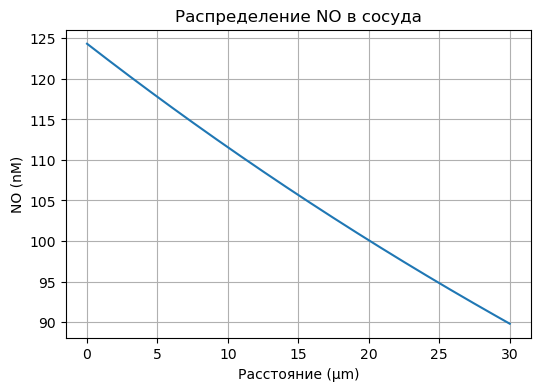

In [555]:
# ==========================================
# ПРОСТРАНСТВЕННАЯ ДИФФУЗИЯ NO
# ==========================================

D_NO = 8.5e-10
k_scav = 0.1
lambda_NO = np.sqrt(D_NO/k_scav)

r_m = vessels_params[vessel_type]["r_m"]
h = 2 * r_m
# координата x (от стенки до стенки)
x = np.linspace(0, r_m, 200)
print (h)
NO_xt = sol_no.y[4][:, None] * np.exp(-x[None, :] / lambda_NO)

plt.figure(figsize=(6,4))
plt.plot(x*1e6, NO_xt[-1]*1e9)
plt.xlabel("Расстояние (µm)")
plt.ylabel("NO (nM)")
plt.title("Распределение NO в сосуда")
plt.grid()
plt.show()